## 1. Project Introduction

### 1.1 Problem Statement

Bike-sharing systems generate large amounts of usage data containing information
about time, weather, seasonality, and working-day conditions.

The goal of this project is to develop regression models that can predict the
total number of bike rentals in a given hour.

### 1.2 Machine Learning Problem

This is a **supervised regression problem** because:

- The input variables describe the conditions for a particular hour.
- The target variable `cnt` represents the total number of bike rentals.
- The target is a continuous numerical value.

### 1.3 Target Variable

The target variable is:

`cnt` — Total number of bike rentals.

### 1.4 Project Goal

The main goal is to compare multiple regression algorithms and identify a model
that provides strong predictive performance while maintaining reliable
generalisation on unseen test data.

## 2. Import Libraries

The libraries required for data manipulation, visualization, preprocessing,
model training, evaluation, hyperparameter tuning, and dimensionality reduction
are imported below.

In [2]:

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PolynomialFeatures
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor

from sklearn.decomposition import PCA

from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

import warnings
warnings.filterwarnings("ignore")

RANDOM_STATE = 42

print("All required libraries imported successfully.")

All required libraries imported successfully.


## 3. Loading the Dataset

The hourly Bike Sharing dataset is loaded into a Pandas DataFrame.

The dataset contains information about weather, season, calendar information, time of day, and bike rental counts.

In [4]:
# Load the hourly Bike Sharing dataset
df = pd.read_csv("../Data/hour.csv")

# Display the first five rows
df.head()


,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


## 4. Initial Data Understanding

Before preprocessing the dataset, we inspect its structure.

The following aspects are examined:

- Number of rows and columns
- Column names
- Data types
- Basic statistical information
- Target variable distribution

In [6]:
# Dataset dimensions
print("Dataset shape:", df.shape)
# Display column names
print("Columns:")
print(df.columns.tolist())

Dataset shape: (17379, 17)
Columns:
['instant', 'dteday', 'season', 'yr', 'mnth', 'hr', 'holiday', 'weekday', 'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed', 'casual', 'registered', 'cnt']


In [7]:
# Display data types and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), object(1)
memory usage: 2.3+ MB


In [8]:
# Statistical summary of numerical columns
df.describe().T

,count,mean,std,min,25%,50%,75%,max
instant,17379.0,8690.000000,5017.029500,1.00,4345.5000,8690.0000,13034.5000,17379.0000
season,17379.0,2.501640,1.106918,1.00,2.0000,3.0000,3.0000,4.0000
yr,17379.0,0.502561,0.500008,0.00,0.0000,1.0000,1.0000,1.0000
mnth,17379.0,6.537775,3.438776,1.00,4.0000,7.0000,10.0000,12.0000
hr,17379.0,11.546752,6.914405,0.00,6.0000,12.0000,18.0000,23.0000
holiday,17379.0,0.028770,0.167165,0.00,0.0000,0.0000,0.0000,1.0000
weekday,17379.0,3.003683,2.005771,0.00,1.0000,3.0000,5.0000,6.0000
workingday,17379.0,0.682721,0.465431,0.00,0.0000,1.0000,1.0000,1.0000
weathersit,17379.0,1.425283,0.639357,1.00,1.0000,1.0000,2.0000,4.0000
temp,17379.0,0.496987,0.192556,0.02,0.3400,0.5000,0.6600,1.0000


In [9]:
# Target variable overview
print("Target variable: cnt")
print("Minimum:", df["cnt"].min())
print("Maximum:", df["cnt"].max())
print("Mean:", df["cnt"].mean())
print("Median:", df["cnt"].median())

Target variable: cnt
Minimum: 1
Maximum: 977
Mean: 189.46308763450142
Median: 142.0


## 5. Data Quality Analysis

Data quality is checked before model development.

We examine:

- Missing values
- Duplicate rows
- Potentially invalid values
- Data types
- Duplicate treatment

These checks help ensure that the dataset is suitable for subsequent analysis and modelling.

In [10]:
# Check missing values
missing_values = df.isnull().sum()

missing_values[missing_values > 0]

Series([], dtype: int64)

In [11]:
# Check duplicate rows
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


In [12]:
# Check unique values for categorical/time-related columns
categorical_check_columns = [
    "season",
    "yr",
    "mnth",
    "hr",
    "holiday",
    "weekday",
    "workingday",
    "weathersit"
]

for col in categorical_check_columns:
    print(f"{col}: {sorted(df[col].unique())}")

season: [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
yr: [np.int64(0), np.int64(1)]
mnth: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12)]
hr: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23)]
holiday: [np.int64(0), np.int64(1)]
weekday: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)]
workingday: [np.int64(0), np.int64(1)]
weathersit: [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]


# 6. Exploratory Data Analysis (EDA)

Exploratory Data Analysis is performed to understand the characteristics of the dataset before model training.

The analysis focuses on:

- Feature distributions
- Target distribution
- Relationships between numerical features
- Correlations
- Feature-target relationships
- Patterns associated with time and weather

## 6.1 Numerical Feature Distributions

Distribution plots are used to understand the range, spread, skewness, and potential extreme values of numerical variables.

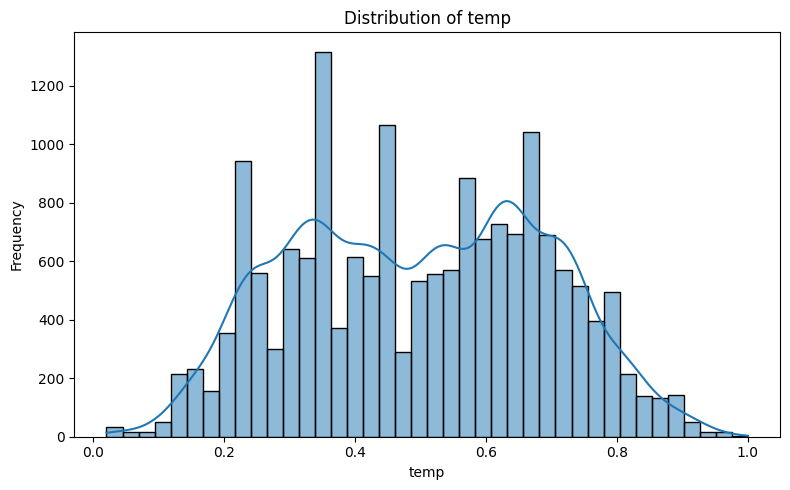

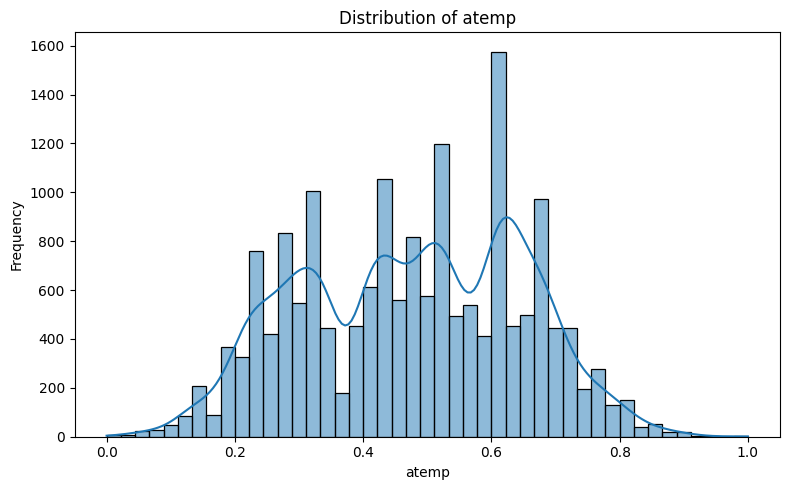

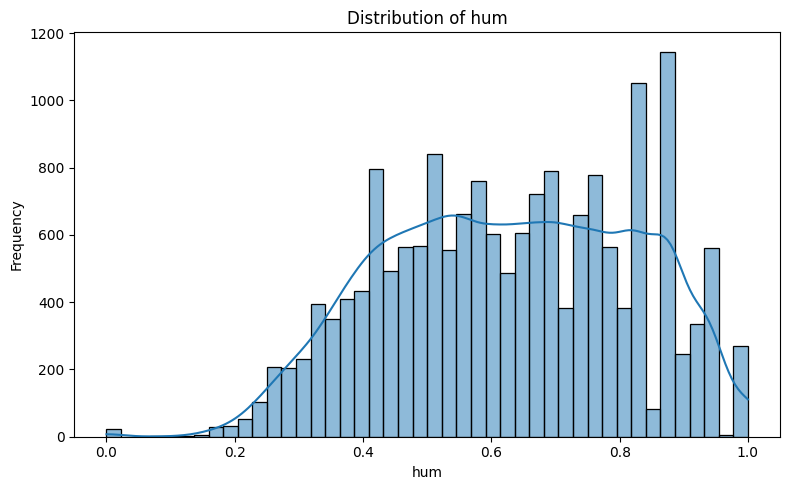

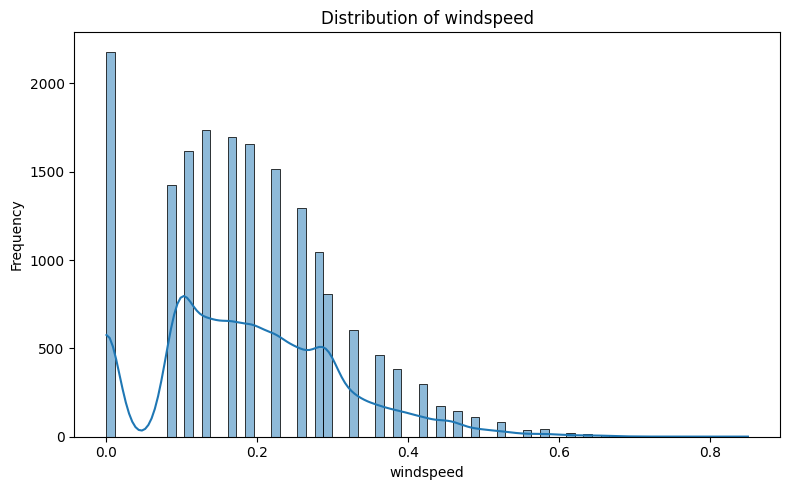

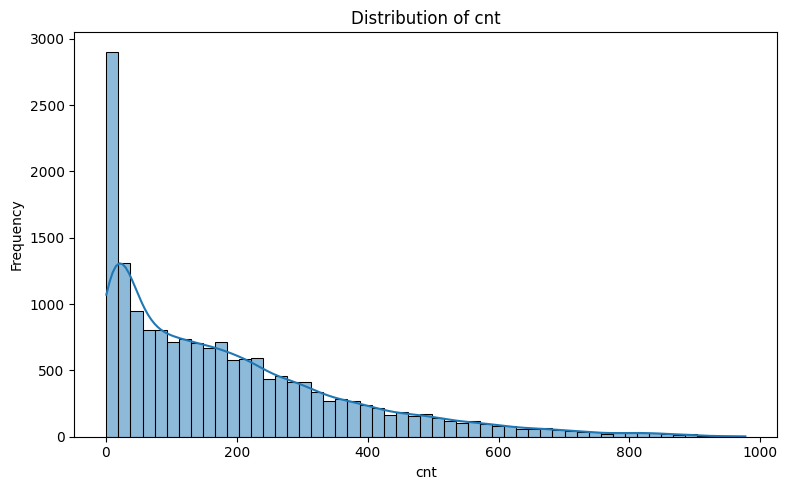

In [13]:
# Numerical columns for EDA
numerical_eda = [
    "temp",
    "atemp",
    "hum",
    "windspeed",
    "cnt"
]

# Plot distributions
for col in numerical_eda:
    plt.figure(figsize=(8, 5))
    sns.histplot(data=df, x=col, kde=True)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()

## 6.2 Categorical and Temporal Feature Distributions

Bar plots are used to understand how observations are distributed across seasons, months, hours, weekdays, working days, and weather conditions.

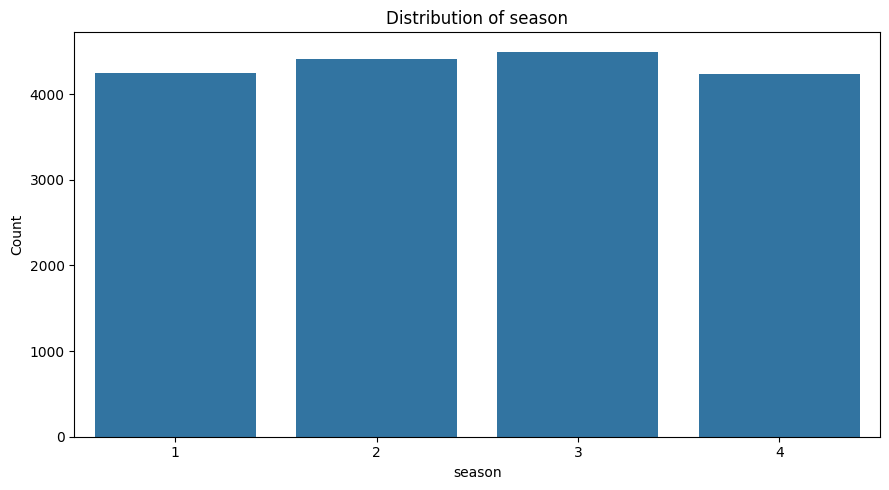

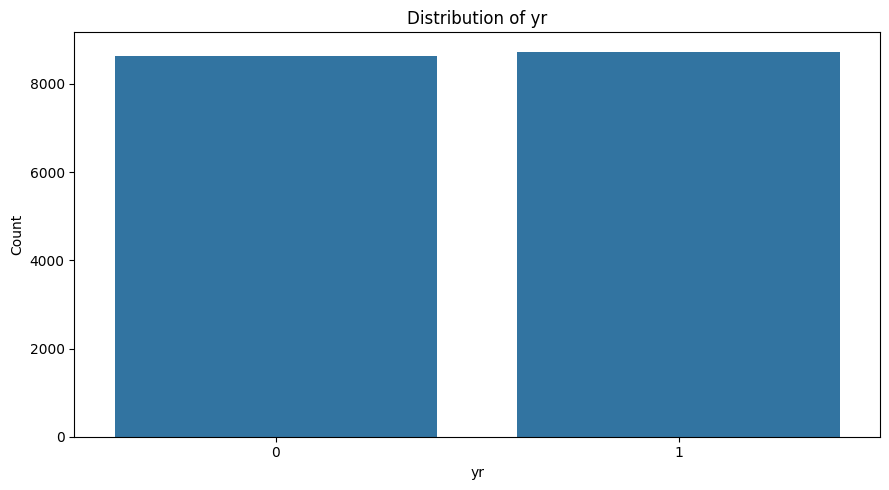

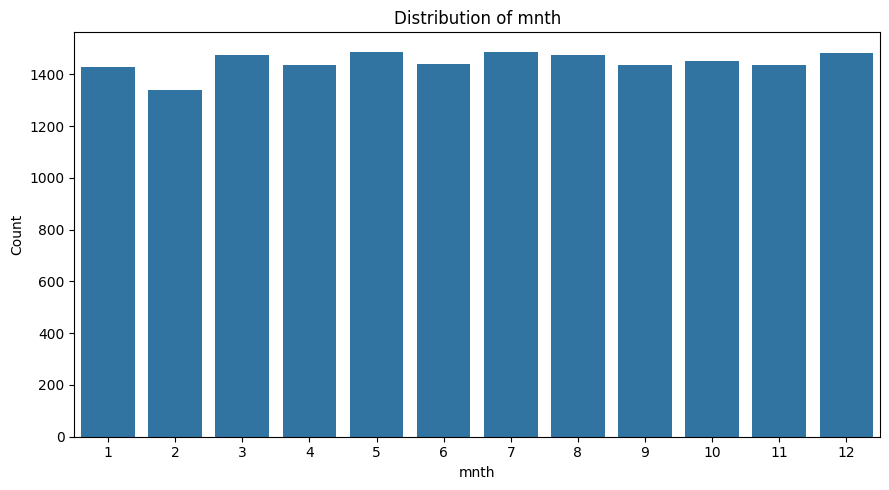

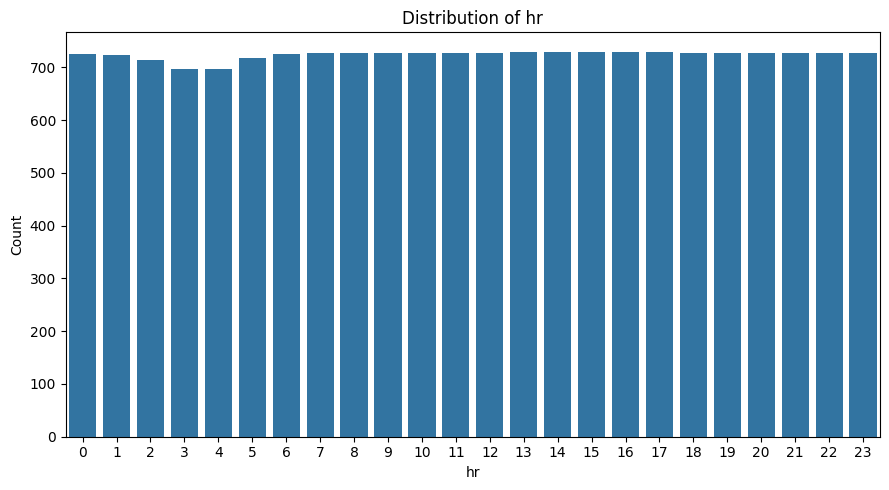

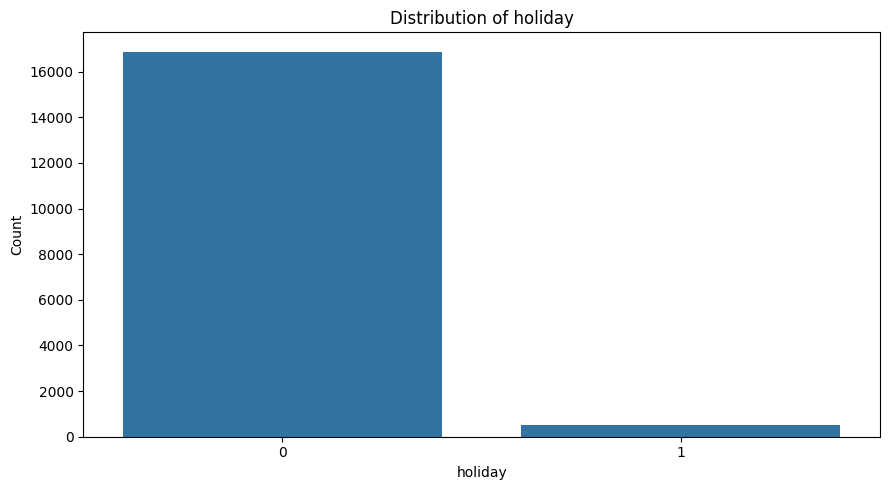

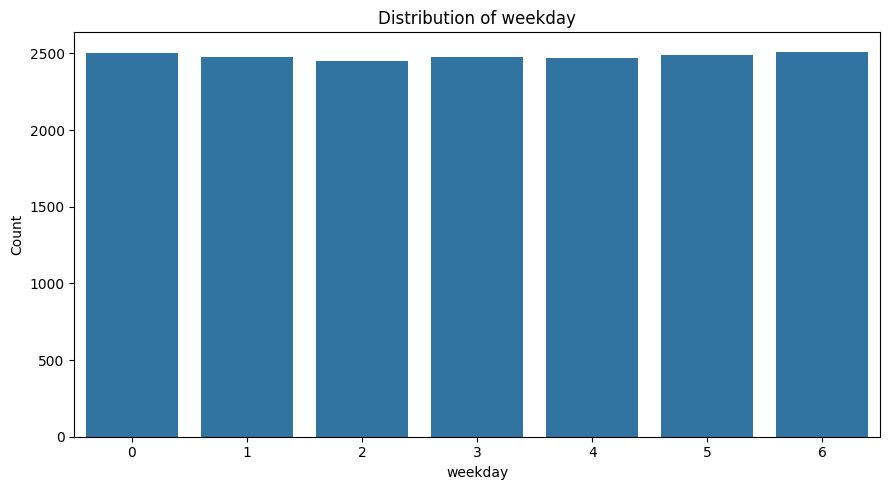

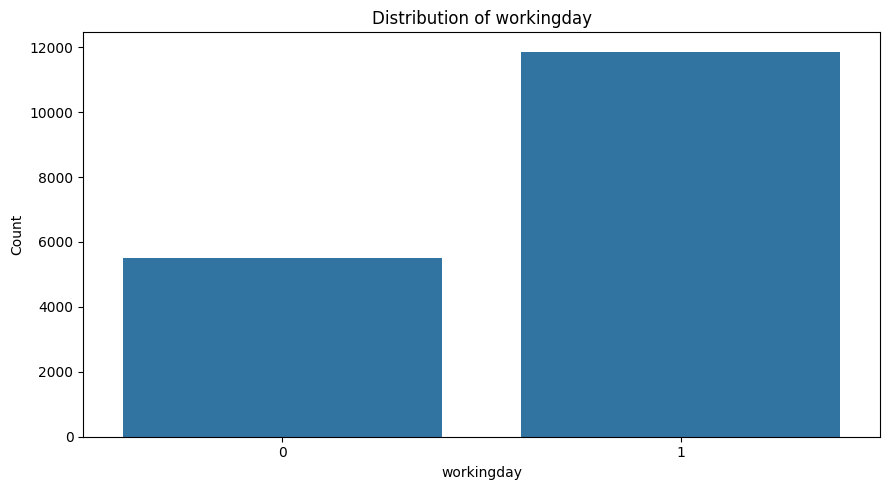

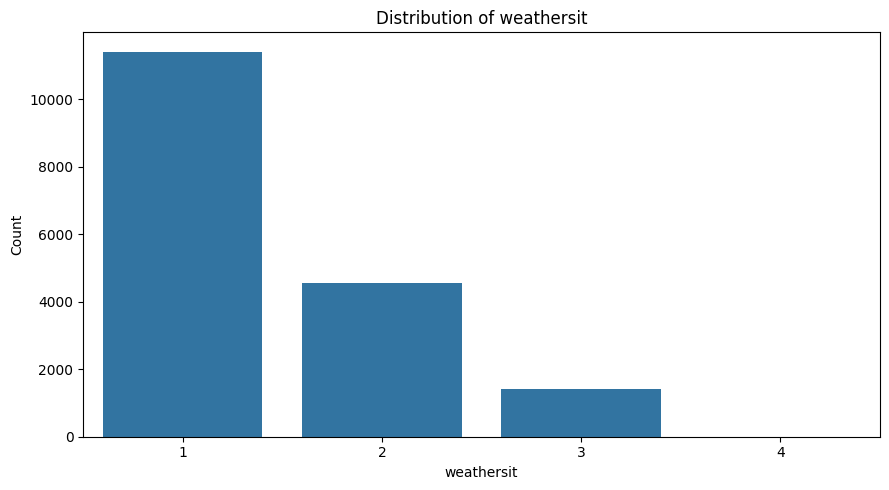

In [14]:
categorical_eda = [
    "season",
    "yr",
    "mnth",
    "hr",
    "holiday",
    "weekday",
    "workingday",
    "weathersit"
]

for col in categorical_eda:
    plt.figure(figsize=(9, 5))
    sns.countplot(data=df, x=col)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

## 6.4 Correlation Analysis

A correlation heatmap is used to examine linear relationships between numerical variables and the target variable.

Correlation values range from -1 to +1:

- Values close to +1 indicate a strong positive linear relationship.
- Values close to -1 indicate a strong negative linear relationship.
- Values close to 0 indicate a weak linear relationship.

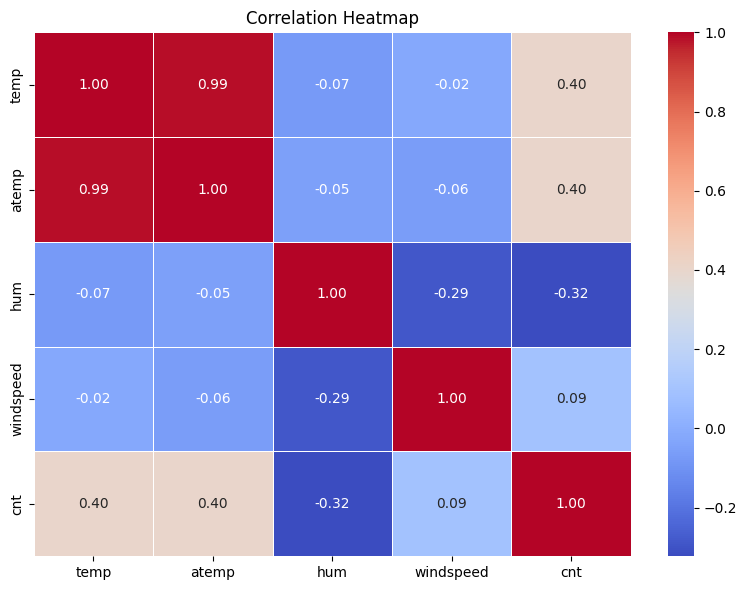

In [15]:
# Select numerical columns for correlation analysis
correlation_columns = [
    "temp",
    "atemp",
    "hum",
    "windspeed",
    "cnt"
]

corr_matrix = df[correlation_columns].corr()

plt.figure(figsize=(8, 6))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

## 6.5 Feature-Target Relationship: Temperature vs Demand

A scatter plot is used to visually examine the relationship between temperature and total bike rental demand.

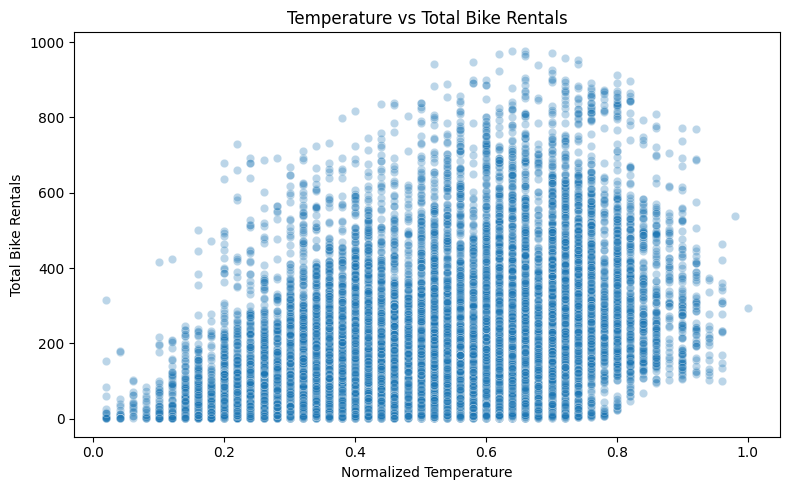

In [16]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="temp",
    y="cnt",
    alpha=0.3
)

plt.title("Temperature vs Total Bike Rentals")
plt.xlabel("Normalized Temperature")
plt.ylabel("Total Bike Rentals")

plt.tight_layout()
plt.show()

## 6.6 Feature-Target Relationship: Humidity vs Demand

A second scatter plot is used to examine the relationship between humidity and total bike rental demand.

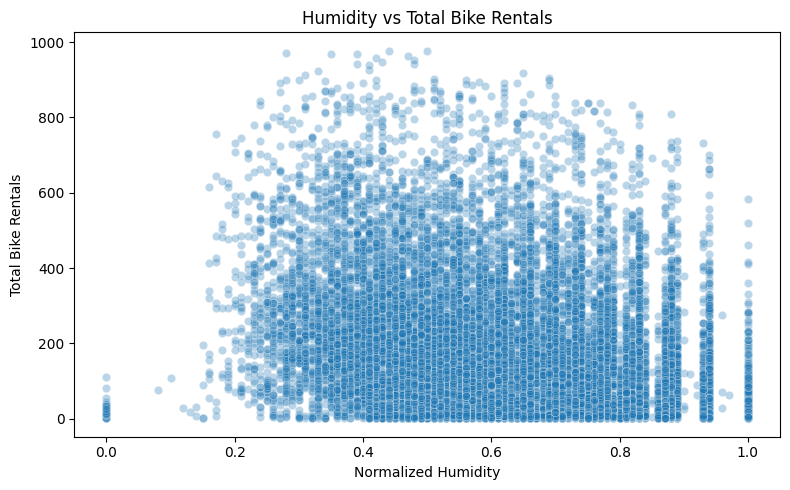

In [17]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="hum",
    y="cnt",
    alpha=0.3
)

plt.title("Humidity vs Total Bike Rentals")
plt.xlabel("Normalized Humidity")
plt.ylabel("Total Bike Rentals")

plt.tight_layout()
plt.show()

# 7. Outlier Analysis

Outliers are examined to determine whether extreme observations are errors or legitimate observations.

In a bike-sharing dataset, unusually high rental counts may represent genuine periods of high demand. Therefore, extreme values should not automatically be removed.

The analysis distinguishes between:

- Invalid/impossible observations
- Legitimate extreme observations

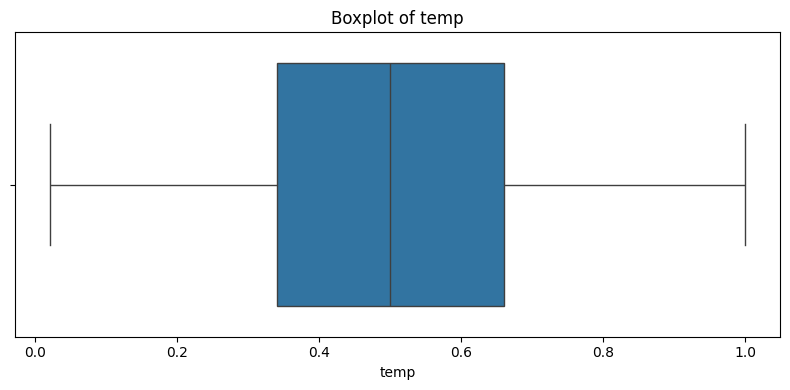

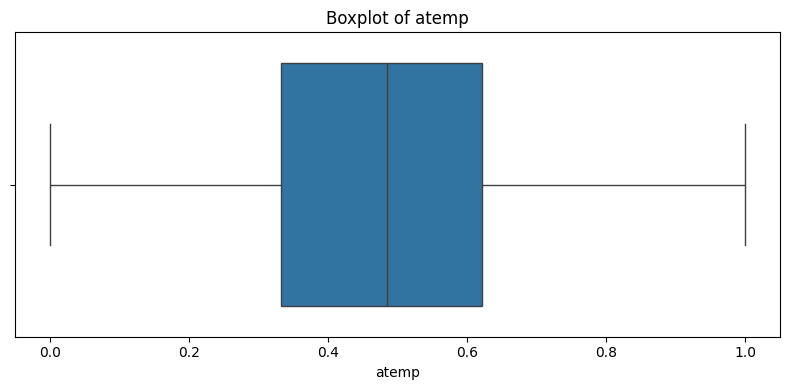

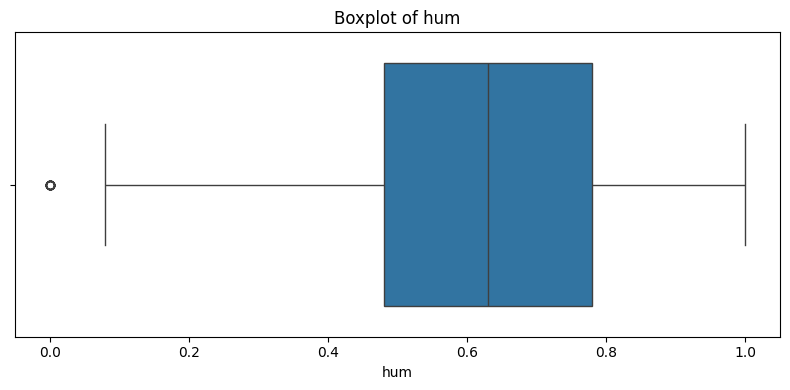

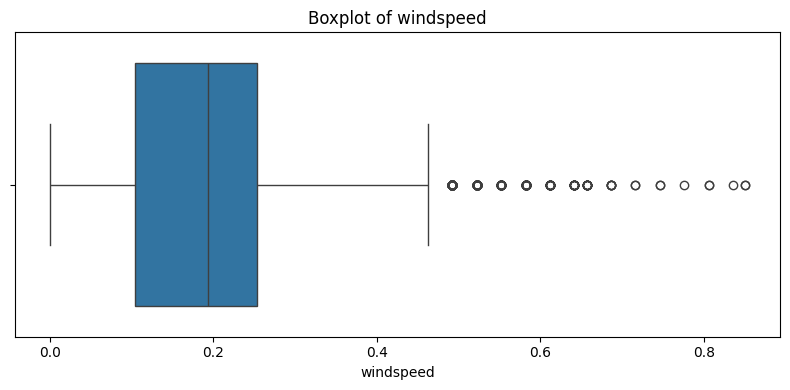

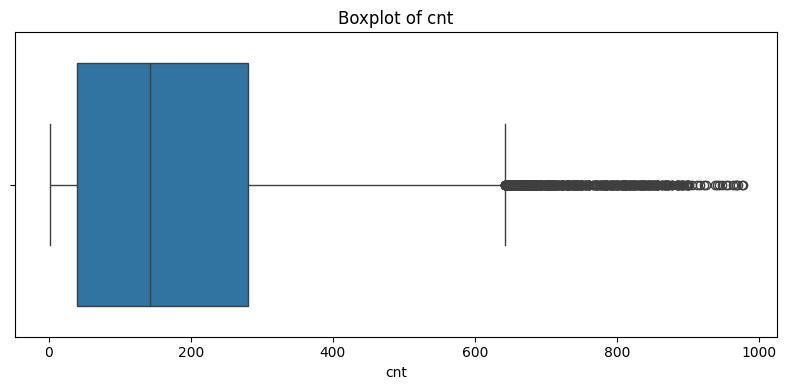

In [18]:
# Boxplots for numerical variables
for col in numerical_eda:
    plt.figure(figsize=(8, 4))

    sns.boxplot(x=df[col])

    plt.title(f"Boxplot of {col}")
    plt.xlabel(col)

    plt.tight_layout()
    plt.show()

# 8. Feature Engineering

Feature engineering creates additional information that may help regression models capture patterns in the data.

The `dteday` column contains date information. It will first be converted into a datetime representation, and the day of the month will be extracted as an additional feature.

The dataset already contains year, month, weekday, and hour information, so these existing variables will not be redundantly recreated.
\

In [5]:
# Convert date column to datetime
df["dteday"] = pd.to_datetime(df["dteday"])

# Extract day of month as an additional feature
df["day"] = df["dteday"].dt.day

# Display the new feature
df[["dteday", "day"]].head()

,dteday,day
0,2011-01-01,1
1,2011-01-01,1
2,2011-01-01,1
3,2011-01-01,1
4,2011-01-01,1


### Why was `day` engineered?

The day of the month may capture short-term variation within each month that is not directly represented by the existing month variable.

This feature is therefore included as an additional temporal predictor and its usefulness will be evaluated through model performance.

# 9. Target Leakage Prevention

Target leakage occurs when information that would not realistically be available at prediction time is used as an input feature.

The target variable is:

`cnt` = total number of bike rentals.

The variables `casual` and `registered` are components of `cnt`:

`cnt = casual + registered`

Therefore, including either of these variables would cause target leakage.

The `instant` column is also excluded because it acts as a record/index identifier rather than a meaningful predictive feature.

The original `dteday` column will also be removed after extracting the engineered `day` feature.

In [6]:
# Define target
TARGET = "cnt"

# Columns excluded from modelling
columns_to_drop = [
    "instant",
    "dteday",
    "casual",
    "registered"
]

# Create modelling dataset
model_df = df.drop(columns=columns_to_drop)

print("Remaining columns:")
print(model_df.columns.tolist())

Remaining columns:
['season', 'yr', 'mnth', 'hr', 'holiday', 'weekday', 'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed', 'cnt', 'day']


# 10. Defining Features and Target

The dataset is separated into:

- `X`: predictor variables
- `y`: target variable

The target variable `cnt` represents total bike rental demand.

In [7]:
X = model_df.drop(columns=[TARGET])
y = model_df[TARGET]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (17379, 13)
Target shape: (17379,)


# 11. Train-Test Split

The dataset is divided into training and testing subsets using an 80:20 split.

The same split will be used for all ten regression algorithms to ensure that their performance comparisons are fair.

`random_state=42` is used to make the experiment reproducible. 

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE
)

print("Training set:", X_train.shape)
print("Testing set :", X_test.shape)

Training set: (13903, 13)
Testing set : (3476, 13)


In [9]:
# Numerical features selected for outlier treatment
outlier_features = ["temp", "atemp", "hum", "windspeed"]

# Calculate IQR bounds using TRAINING DATA ONLY
Q1 = X_train[outlier_features].quantile(0.25)
Q3 = X_train[outlier_features].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Display the calculated bounds
outlier_bounds = pd.DataFrame({
    "Lower Bound": lower_bound,
    "Upper Bound": upper_bound
})

outlier_bounds

,Lower Bound,Upper Bound
temp,-0.14000,1.14000
atemp,-0.09855,1.05305
hum,0.00500,1.24500
windspeed,-0.11930,0.47750


In [10]:
# Apply capping using the training-derived bounds
X_train[outlier_features] = X_train[outlier_features].clip(
    lower=lower_bound,
    upper=upper_bound,
    axis=1
)

X_test[outlier_features] = X_test[outlier_features].clip(
    lower=lower_bound,
    upper=upper_bound,
    axis=1
)

print("Outlier capping completed.")

Outlier capping completed.


### Outlier Treatment

Potential outliers were first identified using the IQR method. Since extreme
values in weather-related variables may represent genuine observations,
these observations were retained rather than removed.

IQR-based capping was applied to the selected continuous predictor variables
(`temp`, `atemp`, `hum`, and `windspeed`). The lower and upper bounds were
calculated using the training data only and then applied to both the training
and testing sets. This reduces the influence of extreme predictor values
while preserving the observations.

The target variable `cnt` was not capped because high rental counts may
represent genuine demand.

# 12. Data Preprocessing

Different types of features require different preprocessing strategies.

### Numerical Features

Numerical features will use:

1. Median imputation
2. StandardScaler

### Categorical / Discrete Features

The following variables represent categorical or discrete states:

- season
- yr
- mnth
- hr
- holiday
- weekday
- workingday
- weathersit

They will use:

1. Most-frequent imputation
2. One-hot encoding

The preprocessing is implemented using a `ColumnTransformer` so that transformations are applied consistently within the modelling pipeline.

In [11]:
# Define categorical and numerical columns
categorical_features = [
    "season",
    "yr",
    "mnth",
    "hr",
    "holiday",
    "weekday",
    "workingday",
    "weathersit"
]

numerical_features = [
    "temp",
    "atemp",
    "hum",
    "windspeed",
    "day"
]

print("Categorical features:")
print(categorical_features)

print("\nNumerical features:")
print(numerical_features)

Categorical features:
['season', 'yr', 'mnth', 'hr', 'holiday', 'weekday', 'workingday', 'weathersit']

Numerical features:
['temp', 'atemp', 'hum', 'windspeed', 'day']


In [12]:
# Numerical preprocessing pipeline
numerical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

# Categorical preprocessing pipeline
categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            )
        )
    ]
)

# Combine both preprocessing pipelines
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numerical_transformer, numerical_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

In [13]:
# Fit preprocessing only on training data
X_train_processed = preprocessor.fit_transform(X_train)

# Apply the already-fitted preprocessing to test data
X_test_processed = preprocessor.transform(X_test)

print("Processed training shape:", X_train_processed.shape)
print("Processed testing shape :", X_test_processed.shape)

Processed training shape: (13903, 62)
Processed testing shape : (3476, 62)


### Preprocessing Verification

The preprocessing object is fitted only using the training data.

The same fitted transformations are then applied to the test data.

This prevents information from the test set from influencing the preprocessing stage and avoids data leakage.

## 12. Regression Model Training

In this section, ten regression algorithms are trained using the same
preprocessed training dataset. Each model is evaluated on the same held-out
test dataset to ensure a fair comparison.

The following algorithms are implemented:

1. Linear Regression
2. Ridge Regression
3. Lasso Regression
4. ElasticNet Regression
5. Polynomial Regression
6. Decision Tree Regressor
7. Random Forest Regressor
8. Gradient Boosting Regressor
9. Support Vector Regressor (SVR)
10. K-Nearest Neighbors Regressor (KNN)

### Model Evaluation Function

To maintain consistency, a common evaluation function is used for all
regression models. The evaluation metrics are R², RMSE, and MAE.

In [15]:
# Function to train and evaluate a regression model
def evaluate_regression_model(model, X_train, X_test, y_train, y_test):
    
    # Train the model
    model.fit(X_train, y_train)
    
    # Generate predictions on the test set
    predictions = model.predict(X_test)
    
    # Calculate evaluation metrics
    r2 = r2_score(y_test, predictions)
    rmse = np.sqrt(mean_squared_error(y_test, predictions))
    mae = mean_absolute_error(y_test, predictions)
    
    return model, predictions, r2, rmse, mae

### 12.1 Linear Regression

Linear Regression is used as the baseline regression model. It assumes a
linear relationship between the input features and the target variable.

In [16]:
linear_model = LinearRegression()

linear_model, linear_predictions, linear_r2, linear_rmse, linear_mae = (
    evaluate_regression_model(
        linear_model,
        X_train_processed,
        X_test_processed,
        y_train,
        y_test
    )
)

print("Linear Regression")
print("R²  :", linear_r2)
print("RMSE:", linear_rmse)
print("MAE :", linear_mae)

Linear Regression
R²  : 0.6814213839692052
RMSE: 100.43865251791378
MAE : 74.09963898865215


### 12.2 Ridge Regression

Ridge Regression applies L2 regularisation to reduce the effect of
multicollinearity and overly large model coefficients.

In [17]:
ridge_model = Ridge(alpha=1.0)

ridge_model, ridge_predictions, ridge_r2, ridge_rmse, ridge_mae = (
    evaluate_regression_model(
        ridge_model,
        X_train_processed,
        X_test_processed,
        y_train,
        y_test
    )
)

print("Ridge Regression")
print("R²  :", ridge_r2)
print("RMSE:", ridge_rmse)
print("MAE :", ridge_mae)

Ridge Regression
R²  : 0.6815549764310562
RMSE: 100.41759138397148
MAE : 74.08711149389251


### 12.3 Lasso Regression

Lasso Regression uses L1 regularisation. It can reduce some feature
coefficients to zero, which can provide a form of feature selection.

In [18]:
lasso_model = Lasso(
    alpha=0.001,
    max_iter=10000
)

lasso_model, lasso_predictions, lasso_r2, lasso_rmse, lasso_mae = (
    evaluate_regression_model(
        lasso_model,
        X_train_processed,
        X_test_processed,
        y_train,
        y_test
    )
)

print("Lasso Regression")
print("R²  :", lasso_r2)
print("RMSE:", lasso_rmse)
print("MAE :", lasso_mae)

Lasso Regression
R²  : 0.681454010398582
RMSE: 100.43350929997202
MAE : 74.09529338149987


### 12.4 ElasticNet Regression

ElasticNet combines L1 and L2 regularisation. It can provide both
coefficient shrinkage and feature selection.

In [19]:
elastic_model = ElasticNet(
    alpha=0.001,
    l1_ratio=0.5,
    max_iter=10000
)

elastic_model, elastic_predictions, elastic_r2, elastic_rmse, elastic_mae = (
    evaluate_regression_model(
        elastic_model,
        X_train_processed,
        X_test_processed,
        y_train,
        y_test
    )
)

print("ElasticNet Regression")
print("R²  :", elastic_r2)
print("RMSE:", elastic_rmse)
print("MAE :", elastic_mae)

ElasticNet Regression
R²  : 0.6818458618558263
RMSE: 100.37171739454863
MAE : 74.05666177439099


### 12.5 Polynomial Regression

Polynomial Regression extends Linear Regression by creating polynomial
combinations of numerical features. A degree-2 polynomial transformation is
used to capture possible nonlinear relationships while keeping the feature
space manageable.

Categorical features are encoded separately and are not subjected to
polynomial expansion.

In [20]:
# Preprocessing pipeline specifically for Polynomial Regression

polynomial_numerical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("polynomial", PolynomialFeatures(
            degree=2,
            include_bias=False
        ))
    ]
)

polynomial_categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=False
        ))
    ]
)

polynomial_preprocessor = ColumnTransformer(
    transformers=[
        ("num", polynomial_numerical_transformer, numerical_features),
        ("cat", polynomial_categorical_transformer, categorical_features)
    ]
)

# Transform the training and test data
X_train_poly = polynomial_preprocessor.fit_transform(X_train)
X_test_poly = polynomial_preprocessor.transform(X_test)

print("Original preprocessed features:", X_train_processed.shape[1])
print("Polynomial features:", X_train_poly.shape[1])

Original preprocessed features: 62
Polynomial features: 77


In [21]:
polynomial_model = LinearRegression()

polynomial_model, polynomial_predictions, polynomial_r2, polynomial_rmse, polynomial_mae = (
    evaluate_regression_model(
        polynomial_model,
        X_train_poly,
        X_test_poly,
        y_train,
        y_test
    )
)

print("Polynomial Regression")
print("R²  :", polynomial_r2)
print("RMSE:", polynomial_rmse)
print("MAE :", polynomial_mae)

Polynomial Regression
R²  : 0.6873057466330709
RMSE: 99.50674427097908
MAE : 73.21147195967937


### 12.11 Regression Model Comparison

The performance of all ten regression algorithms is consolidated into a
single comparison table. The models are ranked according to their R² score.

In [22]:
# Store results from all ten regression models

results = [
    ["Linear Regression", linear_r2, linear_rmse, linear_mae],
    ["Ridge Regression", ridge_r2, ridge_rmse, ridge_mae],
    ["Lasso Regression", lasso_r2, lasso_rmse, lasso_mae],
    ["ElasticNet Regression", elastic_r2, elastic_rmse, elastic_mae],
    ["Polynomial Regression", polynomial_r2, polynomial_rmse, polynomial_mae],
]

results_df = pd.DataFrame(
    results,
    columns=["Model", "R²", "RMSE", "MAE"]
)

# Rank models by R²
results_df = results_df.sort_values(
    by="R²",
    ascending=False
).reset_index(drop=True)

# Display the comparison table
results_df

,Model,R²,RMSE,MAE
0,Polynomial Regression,0.687306,99.506744,73.211472
1,ElasticNet Regression,0.681846,100.371717,74.056662
2,Ridge Regression,0.681555,100.417591,74.087111
3,Lasso Regression,0.681454,100.433509,74.095293
4,Linear Regression,0.681421,100.438653,74.099639
